# E-Commerce Sales Analysis

## Objective
Analyze the **Sample Superstore** dataset using **Python (Pandas)** to identify:
- sales trends over time
- top customers
- category performance
- regional performance
- business insights

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib


## 1. Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Dataset

In [22]:
df = pd.read_csv("Superstore-dataset.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 3. Inspect Basic Information

In [23]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (9994, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [25]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [26]:
df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,9994.0,NaN,NaN,NaN,4997.5,2885.163629,1.0,2499.25,4997.5,7495.75,9994.0
Order ID,9994,5009,CA-2017-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,1237,09-05-2016,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,9994,1334,12/16/2015,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Cleaning and Preparation

In [27]:
# Convert date columns to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

# Extract month and year from Order Date
df["month"] = df["Order Date"].dt.month
df["year"] = df["Order Date"].dt.year

df[["Order Date", "Ship Date", "month", "year"]].head()

,Order Date,Ship Date,month,year
0,2016-11-08,2016-11-11,11.0,2016.0
1,2016-11-08,2016-11-11,11.0,2016.0
2,2016-06-12,NaT,6.0,2016.0
3,2015-10-11,NaT,10.0,2015.0
4,2015-10-11,NaT,10.0,2015.0


In [28]:
# Missing values summary
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Order Date    5952
Ship Date     6096
month         5952
year          5952
dtype: int64

## 5. Analysis

This section answers:
- Which month has the highest sales?
- Which region generates the most revenue?
- Who are the top customers?
- Which category has the highest profit?


In [29]:
# Monthly total sales
monthly_sales = (
    df.groupby(["year", "month"])["Sales"]
    .sum()
    .reset_index()
    .sort_values(["year", "month"])
)

monthly_sales["date"] = pd.to_datetime(
    monthly_sales[["year", "month"]].assign(day=1)
)

monthly_sales.head()

,year,month,Sales,date
0,2014.0,1.0,4923.616,2014-01-01
1,2014.0,2.0,3610.402,2014-02-01
2,2014.0,3.0,8048.773,2014-03-01
3,2014.0,4.0,16040.811,2014-04-01
4,2014.0,5.0,9288.864,2014-05-01


In [30]:
# Top 10 customers by sales
top_customers = (
    df.groupby(["Customer ID", "Customer Name"])["Sales"]
    .sum()
    .reset_index()
    .sort_values("Sales", ascending=False)
)

top_10_customers = top_customers.head(10)
top_10_customers

,Customer ID,Customer Name,Sales
700,SM-20320,Sean Miller,25043.050
741,TC-20980,Tamara Chand,19052.218
621,RB-19360,Raymond Buch,15117.339
730,TA-21385,Tom Ashbrook,14595.620
6,AB-10105,Adrian Barton,14473.571
434,KL-16645,Ken Lonsdale,14175.229
669,SC-20095,Sanjit Chand,14142.334
327,HL-15040,Hunter Lopez,12873.298
683,SE-20110,Sanjit Engle,12209.438
131,CC-12370,Christopher Conant,12129.072


In [31]:
# Percentage contribution of each customer
top_customers["Percent_sales"] = (top_customers["Sales"] / df["Sales"].sum()) * 100
top_customers.head(10)

,Customer ID,Customer Name,Sales,Percent_sales
700,SM-20320,Sean Miller,25043.050,1.090155
741,TC-20980,Tamara Chand,19052.218,0.829367
621,RB-19360,Raymond Buch,15117.339,0.658076
730,TA-21385,Tom Ashbrook,14595.620,0.635365
6,AB-10105,Adrian Barton,14473.571,0.630052
434,KL-16645,Ken Lonsdale,14175.229,0.617065
669,SC-20095,Sanjit Chand,14142.334,0.615633
327,HL-15040,Hunter Lopez,12873.298,0.560391
683,SE-20110,Sanjit Engle,12209.438,0.531492
131,CC-12370,Christopher Conant,12129.072,0.527994


In [32]:
# Total sales by category
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .reset_index()
    .sort_values("Sales", ascending=False)
)

category_sales

,Category,Sales
2,Technology,836154.0330
0,Furniture,741999.7953
1,Office Supplies,719047.0320


In [33]:
# Total profit by category
category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .reset_index()
    .sort_values("Profit", ascending=False)
)

category_profit

,Category,Profit
2,Technology,145454.9481
1,Office Supplies,122490.8008
0,Furniture,18451.2728


In [34]:
# Highest profit category
highest_profit_category = category_profit.iloc[0]
highest_profit_category

Category     Technology
Profit      145454.9481
Name: 2, dtype: object

In [35]:
# Total sales by region
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .reset_index()
    .sort_values("Sales", ascending=False)
)

region_sales

,Region,Sales
3,West,725457.8245
1,East,678781.2400
0,Central,501239.8908
2,South,391721.9050


## 6. Visualizations

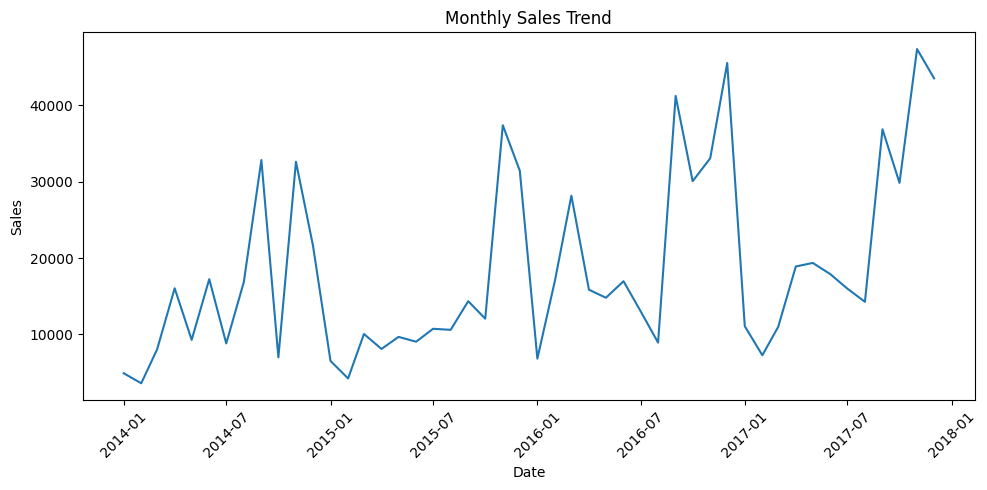

In [36]:
# Monthly sales trend
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales["date"], monthly_sales["Sales"])
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

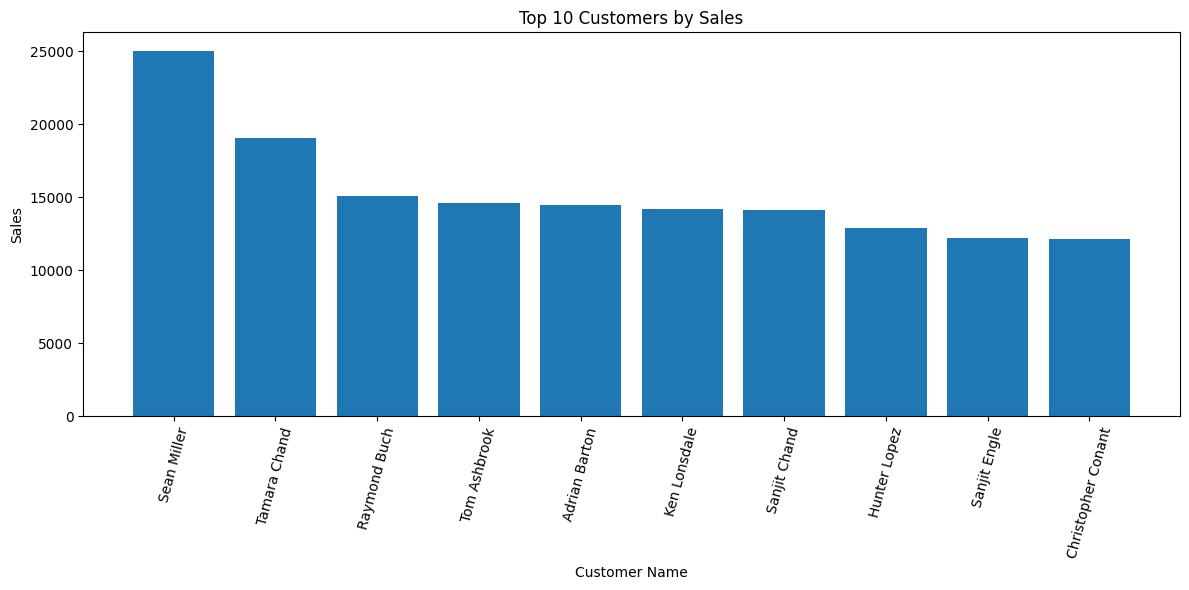

In [37]:
# Top 10 customers by sales
plt.figure(figsize=(12, 6))
plt.bar(top_10_customers["Customer Name"], top_10_customers["Sales"])
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Sales")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

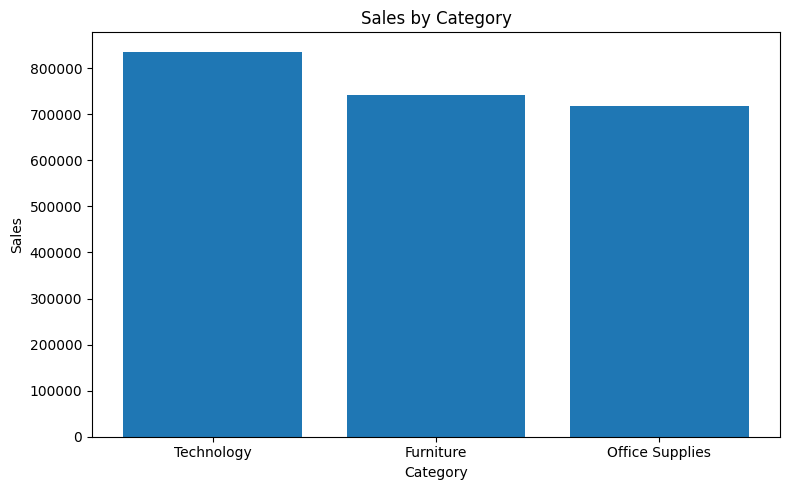

In [38]:
# Sales by category
plt.figure(figsize=(8, 5))
plt.bar(category_sales["Category"], category_sales["Sales"])
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

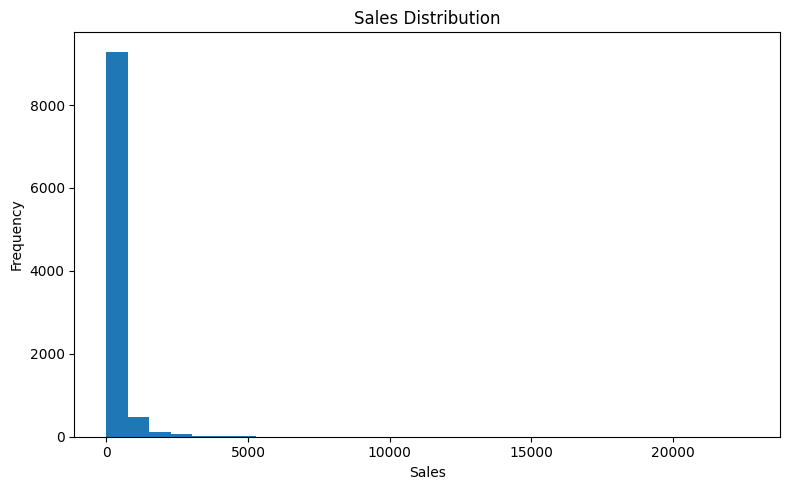

In [39]:
# Sales distribution
plt.figure(figsize=(8, 5))
plt.hist(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 7. Key Insights

1. **Sean Miller generated the highest total sales** among all customers.
2. **West region generated the highest revenue**, making it the best-performing region.
3. **Sales peaked on 21 March 2014**, which may indicate a promotional event or seasonal spike.
4. **South region showed relatively lower sales performance**, suggesting room for improvement.
5. **Sales fluctuate over time**, showing varying demand across months.


## 8. Conclusion

This notebook demonstrates an end-to-end **Python (Pandas)** analysis workflow for an e-commerce dataset, including:
- data inspection
- cleaning
- aggregation
- visualization
- insight generation

It can be used along with the **SQL** and **Power BI** parts of the project to present a full resume-ready portfolio project.
